# Qwen3-VL-4B QLoRA 미니 데모

[Qwen3-VL-4B-Instruct](https://huggingface.co/Qwen/Qwen3-VL-4B-Instruct)를 **4bit QLoRA**로 소량 데이터만 학습하는 체험용 노트북입니다.

| 항목 | 설정 |
|------|------|
| GPU | RTX 3060 12GB 기준 |
| 학습 샘플 | 640개 (스트리밍으로 일부만 다운로드) |
| 예상 학습 시간 | **약 17분** (모델·데이터 최초 다운로드 제외) |
| 전체 실행 | 약 35~40분 (3060 12GB, 최초 1회) |
| 목적 | Qwen3-VL SFT 파이프라인 체험 (실용 품질 파인튜닝 아님) |

**흐름:** 환경 설정 → 소량 데이터 로드 → QLoRA 학습 → LoRA 어댑터 추론 테스트 → **한국어 복합 추론**

> 이전 노트북: `06_qwen3_vl_example.ipynb` (추론 전용) · `05_llava_qlora_mini_train.ipynb` (LLaVA QLoRA)

Qwen3-VL은 4B 파라미터로 LLaVA-7B보다 가볍고, **한국어·OCR**을 네이티브 지원합니다. TRL `SFTTrainer` + 4bit QLoRA로 12GB VRAM에서 학습 가능합니다.

## 1. 환경 설정

```bash
pip install -r requirements.txt
```

추가 패키지: `trl`, `peft`, `bitsandbytes`, `datasets`

Qwen3-VL은 **transformers 4.57.0 이상**이 필요합니다.

> **Windows**: `bitsandbytes>=0.43` 이상 필요. CUDA GPU가 없으면 QLoRA 학습은 불가합니다.

In [1]:
# QLoRA 학습·추론에 필요한 추가 패키지 설치
# - transformers : Qwen3-VL 지원 (4.57.0 이상)
# - trl      : SFTTrainer (지도학습 파인튜닝)
# - peft     : LoRA 어댑터
# - bitsandbytes : 4bit 양자화 (QLoRA)
# - datasets : Hugging Face 데이터셋 로드
# %pip install -q "transformers>=4.57.0" "trl>=0.9.0" "peft>=0.10.0" "bitsandbytes>=0.43.0" "datasets>=2.18.0"


In [2]:
import gc
import inspect
import time
from pathlib import Path

import torch
from datasets import Dataset, load_dataset
from peft import LoraConfig, prepare_model_for_kbit_training
from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen3VLForConditionalGeneration,
)
from trl import SFTConfig, SFTTrainer

# ─────────────────────────────────────────────
# 하이퍼파라미터 (RTX 3060 12GB · 학습 ~17분 목표)
# ─────────────────────────────────────────────

# Hugging Face 모델·데이터셋 ID
MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"          # 베이스 VLM (4B, 한국어·OCR 네이티브)
DATASET_ID = "HuggingFaceH4/llava-instruct-mix-vsft"  # 이미지+대화 SFT 데이터 (LLaVA 형식)
OUTPUT_DIR = "./qwen3-vl-4b-qlora-mini"           # LoRA 어댑터 저장 경로

# 학습 규모 — 늘리면 품질↑, 시간·VRAM↑
MAX_SAMPLES = 640          # 64→640: optimizer 스텝 16→160 (~17분)
MAX_TEXT_CHARS = 256       # 긴 텍스트 → 시퀀스 길이↑ → VRAM↑
NUM_EPOCHS = 1            # 데이터를 몇 번 반복 학습할지
# Qwen3-VL vision 토큰 상한 (기본값은 HD 이미지에서 8000+ 토큰 → 12GB OOM)
MIN_PIXELS = 256 * 28 * 28   # 200,704 px
MAX_PIXELS = 256 * 28 * 28   # LLaVA(~576)급으로 제한, 학습용 체험에 충분
BATCH_SIZE = 1            # GPU에 한 번에 올리는 샘플 수 (12GB면 1 권장)
GRAD_ACCUM = 4            # N 스텝마다 역전파 → 유효 배치 = 1 × 4 = 4

# LoRA 설정 — rank가 클수록 표현력↑, VRAM·시간↑
LORA_R = 8                # LoRA 저랭크 차원
LORA_ALPHA = 16           # LoRA 스케일 (보통 r의 2배)
LEARNING_RATE = 2e-4        # LoRA 학습률

# 연산 환경
device = "cuda" if torch.cuda.is_available() else "cpu"
compute_dtype = torch.float16  # RTX 3060: fp16 (bf16 AMP 충돌 방지)

if device != "cuda":
    raise RuntimeError("CUDA GPU가 필요합니다. QLoRA 학습은 CPU에서 실행할 수 없습니다.")

# 학습 전 GPU·하이퍼파라미터 요약 출력
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"학습 샘플: {MAX_SAMPLES} | max_text_chars: {MAX_TEXT_CHARS}")
print(f"이미지 pixel 상한: {MAX_PIXELS:,} (vision 토큰 ~720개 수준)")
print(f"예상 optimizer 스텝: {MAX_SAMPLES * NUM_EPOCHS // (BATCH_SIZE * GRAD_ACCUM)} ({NUM_EPOCHS} epoch)")


GPU: NVIDIA GeForce RTX 3060
VRAM: 12.0 GB
학습 샘플: 640 | max_text_chars: 256
이미지 pixel 상한: 200,704 (vision 토큰 ~720개 수준)
예상 optimizer 스텝: 160 (1 epoch)


## 2. 소량 데이터셋 로드

`HuggingFaceH4/llava-instruct-mix-vsft` 전체(약 198GB)를 받지 않도록 **스트리밍**으로 앞부분만 가져옵니다.

LLaVA 형식(`messages` + `images`)을 Qwen3-VL chat 형식으로 변환해 사용합니다.

In [3]:
def load_mini_dataset(dataset_id: str, max_samples: int) -> Dataset:
    """스트리밍으로 앞에서 max_samples개만 수집.

    llava-instruct-mix-vsft 전체는 약 198GB이므로,
    streaming=True로 필요한 만큼만 네트워크에서 받아 OOM·시간을 줄입니다.

    각 샘플 구조:
      - messages: [{role, content:[{type,text/image}, ...]}, ...]
      - images  : [PIL.Image, ...]
    """
    stream = load_dataset(dataset_id, split="train", streaming=True)
    samples = []
    for i, row in enumerate(stream):
        samples.append(row)
        if i + 1 >= max_samples:
            break
    return Dataset.from_list(samples)


print(f"데이터셋 로드 중 (최대 {MAX_SAMPLES}개)...")
t0 = time.time()
train_dataset = load_mini_dataset(DATASET_ID, MAX_SAMPLES)
print(f"로드 완료: {len(train_dataset)}개 ({time.time() - t0:.1f}초)")
print(f"컬럼: {train_dataset.column_names}")
# 첫 샘플 user 메시지 일부 확인 (데이터 형식 검증용)
print(f"메시지 예시 (user): {train_dataset[0]['messages'][1]['content'][0]}")


데이터셋 로드 중 (최대 640개)...


Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

로드 완료: 640개 (11.0초)
컬럼: ['messages', 'images']
메시지 예시 (user): {'index': None, 'text': 'Donna Eden', 'type': 'text'}


## 3. QLoRA 모델 로드

- **4bit 양자화**로 VRAM 절약 (~6~9GB)
- **visual(비전 인코더) 동결** → LLM LoRA만 학습
- `q_proj`, `v_proj`에 LoRA 적용 (메모리 최소화)

> Qwen3-VL + gradient checkpointing 사용 시 `get_input_embeddings` 패치가 필요할 수 있습니다.

> **OOM 주의**: Qwen3 기본 `image_processor`는 HD 이미지에서 vision 토큰 **8000개+**를 만듭니다. LLaVA(~576)보다 훨씬 길어 12GB에서 학습 시 OOM이 납니다. 아래 `max_pixels` 제한이 필수입니다.

In [4]:
def clear_gpu():
    """Python GC + CUDA 캐시 비우기."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()  # 비동기 연산 완료 대기


def release_models(*names):
    """노트북 재실행 시 GPU에 남은 모델 변수를 안전하게 해제.

    del만 하면 참조가 남을 수 있어, 존재하는 이름만 삭제 후 clear_gpu() 호출.
    """
    g = globals()
    for name in names:
        if name in g:
            del g[name]
    clear_gpu()


def freeze_vision_modules(model):
    """Qwen3-VL visual encoder 가중치 동결.

    QLoRA는 LLM 쪽 LoRA만 학습합니다. visual까지 학습하면 VRAM·시간이 크게 늘어납니다.
    """
    for name, param in model.named_parameters():
        if ".visual." in name or name.startswith("visual."):
            param.requires_grad = False


def patch_input_embeddings(model):
    """gradient checkpointing + Qwen3-VL NotImplementedError 방지."""
    language_model = getattr(getattr(model, "model", None), "language_model", None)
    if language_model is not None and hasattr(language_model, "embed_tokens"):
        def get_input_embeddings(self):
            return self.model.language_model.embed_tokens

        model.get_input_embeddings = get_input_embeddings.__get__(model, type(model))


def configure_qwen3_processor(processor, min_pixels: int, max_pixels: int):
    """학습용 이미지 해상도 상한 — vision 토큰 수를 줄여 VRAM OOM 방지."""
    processor.image_processor.min_pixels = min_pixels
    processor.image_processor.max_pixels = max_pixels
    return processor


# ── 4bit 양자화 설정 (QLoRA 핵심) ──
# 베이스 4B 가중치를 4bit로 올려 VRAM을 ~6~9GB 수준으로 줄입니다.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,                         # 4bit 가중치 로드
    bnb_4bit_quant_type="nf4",                 # NormalFloat4 양자화
    bnb_4bit_compute_dtype=compute_dtype,      # 연산 시 캐스팅 dtype
    bnb_4bit_use_double_quant=True,            # 이중 양자화로 추가 메모리 절약
)

print(f"모델 로드 중: {MODEL_ID} (4bit QLoRA)...")
# processor = 토크나이저 + 이미지 전처리기 통합
processor = AutoProcessor.from_pretrained(MODEL_ID)
processor = configure_qwen3_processor(processor, MIN_PIXELS, MAX_PIXELS)
processor.tokenizer.padding_side = "right"     # 배치 패딩을 오른쪽에 추가
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

# 베이스 Qwen3-VL 로드 (학습 시 LoRA가 이 위에 붙음)
model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",       # GPU에 자동 배치
    torch_dtype=compute_dtype,
)
# k-bit 학습 준비: gradient checkpointing 등 활성화
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)
model.config.use_cache = False  # 학습 시 KV cache 비활성화 (VRAM 절약)
patch_input_embeddings(model)
freeze_vision_modules(model)

# LoRA 어댑터 설정 — attention의 q_proj, v_proj만 미세조정
peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "v_proj"],  # 메모리 최소화용 타깃
    task_type="CAUSAL_LM",
)

allocated = torch.cuda.memory_allocated() / 1024**3
print(f"모델 로드 완료 | GPU 할당: {allocated:.2f} GB")

# ── vision 토큰 진단 (max_pixels 제한 효과 확인) ──
_diag_img = train_dataset[0]["images"][0].convert("RGB")
_diag_grid = processor.image_processor([_diag_img], return_tensors="pt")["image_grid_thw"][0]
print(f"첫 샘플 vision 토큰(제한 후): {int(_diag_grid[1] * _diag_grid[2])} (기본값 대비 8000+ → OOM 원인)")
del _diag_img, _diag_grid


모델 로드 중: Qwen/Qwen3-VL-4B-Instruct (4bit QLoRA)...


W0613 22:54:22.501000 21616 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


모델 로드 완료 | GPU 할당: 3.44 GB
첫 샘플 vision 토큰(제한 후): 720 (기본값 대비 8000+ → OOM 원인)


## 4. 데이터 콜레이터 & 학습 설정

VLM은 `max_length` truncation을 쓰면 vision 토큰이 잘려 오류가 납니다. 텍스트만 미리 자르고 `max_length=None`을 유지합니다.

Qwen3-VL은 이미지마다 **동적 vision 토큰**을 생성합니다. `max_pixels` 없이 HD 이미지를 쓰면 LLaVA 대비 10배+ 긴 시퀀스가 되어 역전파 시 VRAM이 부족합니다.

In [5]:
def trim_messages(messages, max_chars: int):
    """대화 messages에서 텍스트만 글자 수로 자름.

    VLM은 processor truncation(max_length)을 쓰면
    vision 토큰(수백~수천 개)이 input_ids에서 잘려 오류가 납니다.
    → 텍스트만 미리 자르고, processor에는 truncation을 쓰지 않습니다.
    """
    trimmed = []
    for msg in messages:
        content = []
        for item in msg["content"]:
            if item.get("type") == "text" and len(item["text"]) > max_chars:
                content.append({"type": "text", "text": item["text"][:max_chars]})
            else:
                content.append(item)  # image placeholder 등은 그대로 유지
        trimmed.append({"role": msg["role"], "content": content})
    return trimmed


def to_qwen3_messages(messages, images):
    """LLaVA vsft messages → Qwen3-VL chat (이미지를 content에 embed)."""
    img_idx = 0
    converted = []
    for msg in messages:
        content = []
        for item in msg["content"]:
            if item.get("type") == "image":
                content.append({"type": "image", "image": images[img_idx].convert("RGB")})
                img_idx += 1
            elif item.get("type") == "text":
                content.append({"type": "text", "text": item["text"]})
        converted.append({"role": msg["role"], "content": content})
    return converted


def mask_vision_tokens(labels, tokenizer):
    """vision 특수 토큰을 labels에서 -100으로 마스킹 (loss 계산 제외)."""
    for token in (
        "<|vision_start|>",
        "<|vision_end|>",
        "<|vision_pad|>",
        "<|image_pad|>",
        "<|video_pad|>",
    ):
        token_id = tokenizer.convert_tokens_to_ids(token)
        if token_id is not None and token_id != tokenizer.unk_token_id:
            labels[labels == token_id] = -100
    return labels


def collate_fn(examples):
    """DataLoader가 호출하는 배치 전처리 함수.

    1) LLaVA messages → Qwen3-VL chat 형식 변환
    2) chat template → 문자열
    3) processor로 텐서화
    4) labels에서 pad·vision 토큰 마스킹 (-100 = loss 제외)
    """
    conversations = [
        trim_messages(to_qwen3_messages(ex["messages"], ex["images"]), MAX_TEXT_CHARS)
        for ex in examples
    ]
    texts = [
        processor.apply_chat_template(
            conv,
            tokenize=False,
            add_generation_prompt=False,  # 학습: assistant 답까지 포함
        ).strip()
        for conv in conversations
    ]
    # Qwen3-VL 배치 형식: 샘플마다 이미지 리스트
    images = []
    for conv in conversations:
        sample_images = []
        for msg in conv:
            for item in msg["content"]:
                if item.get("type") == "image":
                    sample_images.append(item["image"])
        images.append(sample_images)

    # truncation 사용 금지 — vision 토큰 개수와 input_ids 불일치 방지
    batch = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
    )

    # Causal LM 학습용 labels (input_ids 복사)
    labels = batch["input_ids"].clone()
    # 패딩 토큰은 loss 계산에서 제외
    labels[labels == processor.tokenizer.pad_token_id] = -100
    labels = mask_vision_tokens(labels, processor.tokenizer)
    batch["labels"] = labels
    return batch


# ── SFTTrainer 학습 인자 ──
sft_kwargs = dict(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    gradient_checkpointing=True,               # activation 재계산으로 VRAM 절약
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="paged_adamw_8bit",                  # 8bit 옵티마이저 (VRAM 절약)
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=4,
    save_strategy="no",                        # 미니 데모: 중간 체크포인트 생략
    eval_strategy="no",
    fp16=False,
    bf16=False,  # QLoRA+PEFT: fp16 AMP와 bf16 gradient dtype 충돌 방지
    max_grad_norm=0.3,                         # gradient clipping
    report_to="none",                          # wandb 등 비활성화
    remove_unused_columns=False,               # VLM: images 컬럼 유지 필수
    dataset_kwargs={"skip_prepare_dataset": True},  # collate_fn이 직접 전처리
    dataloader_num_workers=0,                  # Windows 노트북: 0 권장
    max_length=None,  # VLM: truncation 시 vision 토큰 불일치 → None 필수
    assistant_only_loss=False,  # TRL: VLM은 assistant_only_loss 미지원
)

training_args = SFTConfig(**sft_kwargs)
print("학습 설정 완료")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


학습 설정 완료


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21616\29429072.py:124: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  training_args = SFTConfig(**sft_kwargs)


## 5. QLoRA 학습 실행

640샘플 × 1 epoch × batch 1 × grad_accum 4 → **약 160 스텝** (RTX 3060에서 ~17분 예상)

In [ ]:
# SFTTrainer에 넘길 인자 묶음
trainer_kwargs = dict(
    model=model,                   # 4bit로 로드된 베이스 + LoRA 적용 예정
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collate_fn,      # 위에서 정의한 VLM 배치 함수
    peft_config=peft_config,       # Trainer가 LoRA 어댑터를 자동 부착
)

# TRL 버전별 인자명 차이 (신버전: processing_class / 구버전: tokenizer)
if "processing_class" in inspect.signature(SFTTrainer.__init__).parameters:
    trainer_kwargs["processing_class"] = processor
else:
    trainer_kwargs["tokenizer"] = processor.tokenizer

trainer = SFTTrainer(**trainer_kwargs)

print("=" * 50)
print("학습 시작")
train_start = time.time()
train_result = trainer.train()  # 실제 QLoRA 역전파·가중치 업데이트
train_minutes = (time.time() - train_start) / 60

print("=" * 50)
print(f"학습 완료 | 소요 시간: {train_minutes:.1f}분")
print(f"train_loss: {train_result.training_loss:.4f}")
# if train_minutes > 25:
#     print("⚠ 25분 초과 — MAX_SAMPLES를 줄이거나 MAX_TEXT_CHARS를 낮춰 보세요.")
# elif train_minutes < 12:
#     print(f"⚠ {train_minutes:.1f}분 — MAX_SAMPLES를 늘리면 학습 시간이 길어집니다.")
# else:
#     print(f"✓ ~17분 학습 목표 구간 ({train_minutes:.1f}분)")

# RTX 3060 : 약 16~17분 소요 (640샘플 · 160스텝)


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


학습 시작


Step,Training Loss
4,3.206531
8,2.645755
12,1.632701
16,1.475990
20,0.941537
24,1.189113
28,0.669668
32,1.003302
36,0.863711
40,0.595126


학습 완료 | 소요 시간: 16.8분
train_loss: 0.8123


In [7]:
# LoRA 어댑터만 저장 (~수십 MB) — 베이스 4B 전체는 저장하지 않음
# 추론 시 Hugging Face에서 베이스 모델을 다시 로드하고 어댑터를 attach 합니다.
trainer.save_model(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)  # chat template·이미지 전처리(max_pixels) 설정
print(f"어댑터 저장: {Path(OUTPUT_DIR).resolve()}")


어댑터 저장: C:\MyCursorLab\07_Vision_Language_Model\qwen3-vl-4b-qlora-mini


## 6. 학습 후 추론 테스트

저장된 LoRA 어댑터를 로드해 학습 데이터 첫 샘플로 간단히 생성해 봅니다.

> **이 셀만 단독 실행 가능** — 재실행 시 이전 `infer_model`이 GPU에 남아 있으면 VRAM 부족으로 로드 실패할 수 있습니다.

로드 전 VRAM: 3.47 GB


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


로드 후 VRAM: 6.19 GB


c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


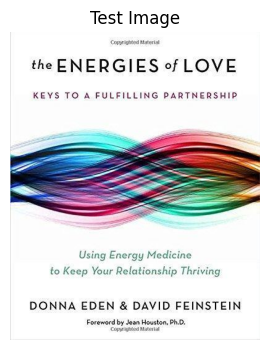

질문: Who wrote this book?

LoRA 모델 답변: Donna Eden


In [8]:
# ═══════════════════════════════════════════════════════════
# 학습 후 추론 테스트 블록 (단독 실행 가능)
# ═══════════════════════════════════════════════════════════
import gc

import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from peft import PeftModel
from transformers import AutoProcessor, BitsAndBytesConfig, Qwen3VLForConditionalGeneration

# 앞 블록을 실행하지 않았을 때 쓸 기본값 (globals에 있으면 그대로 사용)
MODEL_ID = globals().get("MODEL_ID", "Qwen/Qwen3-VL-4B-Instruct")
OUTPUT_DIR = globals().get("OUTPUT_DIR", "./qwen3-vl-4b-qlora-mini")
compute_dtype = globals().get("compute_dtype", torch.float16)


def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def release_models(*names):
    """재실행 시 이전 infer_model/base_model이 GPU에 남지 않도록 해제."""
    g = globals()
    for name in names:
        if name in g:
            del g[name]
    clear_gpu()


def move_inputs_to_model(inputs, model):
    """Qwen3-VL 입력 텐서를 모델 디바이스·dtype에 맞게 이동."""
    device = next(model.parameters()).device
    moved = {}
    for key, value in inputs.items():
        if not hasattr(value, "to"):
            moved[key] = value
            continue
        if key == "pixel_values":
            moved[key] = value.to(device, dtype=compute_dtype)
        else:
            moved[key] = value.to(device)
    return moved


# ── 1) 이전 모델 해제 (재실행 필수) ──
release_models("infer_model", "base_model", "trainer", "model", "inputs", "output_ids")
print(f"로드 전 VRAM: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# ── 2) 4bit 베이스 + LoRA 어댑터 로드 ──
if "bnb_config" not in globals():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )

# 학습 때 저장한 processor 우선 사용 (chat template·max_pixels 일치)
if "processor" not in globals():
    processor = AutoProcessor.from_pretrained(OUTPUT_DIR)

MIN_PIXELS = globals().get("MIN_PIXELS", 256 * 28 * 28)
MAX_PIXELS = globals().get("MAX_PIXELS", 256 * 28 * 28)
if "configure_qwen3_processor" in globals():
    processor = configure_qwen3_processor(processor, MIN_PIXELS, MAX_PIXELS)
else:
    processor.image_processor.min_pixels = MIN_PIXELS
    processor.image_processor.max_pixels = MAX_PIXELS

base_model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=compute_dtype,
)
# OUTPUT_DIR의 LoRA 가중치를 베이스에 부착
infer_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
infer_model.eval()  # dropout 등 비활성화

print(f"로드 후 VRAM: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# ── 3) 테스트용 샘플 1개 준비 ──
if "train_dataset" in globals():
    sample = train_dataset[0]
else:
    # 학습 블록 없이 추론만 할 때: 스트리밍으로 1개만 받기
    DATASET_ID = globals().get("DATASET_ID", "HuggingFaceH4/llava-instruct-mix-vsft")
    sample = next(iter(load_dataset(DATASET_ID, split="train", streaming=True)))

test_image = sample["images"][0].convert("RGB")
# user 역할 메시지에서 텍스트 질문만 추출
user_text = next(
    c["text"]
    for m in sample["messages"]
    if m["role"] == "user"
    for c in m["content"]
    if c.get("type") == "text"
)

# ── 4) 추론 프롬프트 구성 및 생성 ──
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": test_image},
            {"type": "text", "text": user_text},
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
)
inputs = move_inputs_to_model(inputs, infer_model)

with torch.inference_mode():
    output_ids = infer_model.generate(**inputs, max_new_tokens=128, do_sample=False)

# ── 5) 결과 디코딩 및 출력 ──
input_len = inputs["input_ids"].shape[1]
answer = processor.decode(output_ids[0, input_len:], skip_special_tokens=True).strip()

plt.figure(figsize=(6, 4))
plt.imshow(test_image)
plt.axis("off")
plt.title("Test Image")
plt.show()

print(f"질문: {user_text}")
print(f"LoRA 모델 답변: {answer}")


## 7. 한국어 복합 추론 (LoRA 모델)

앞 셀에서 로드한 `infer_model`·`processor`를 **재사용**합니다 (VRAM 절약).

다음 시나리오를 실행합니다:
1. **구조화된 한국어 VQA** — 객체 나열·개수·색상·분위기 등 복합 질문
2. **다중 턴 대화** — 이전 답변 맥락을 이어 후속 질문
3. **지시 따르기** — JSON 형식 출력 요청

> Qwen3-VL은 한국어를 네이티브 지원합니다. 640샘플 LoRA이므로 64샘플 대비 스타일 반영은 조금 나아질 수 있으나, 여전히 **체험 수준**입니다.

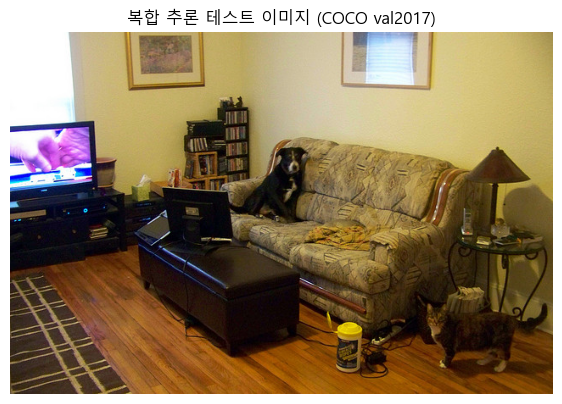

[1] 구조화된 한국어 VQA
Q1. 이 이미지를 한국어로 자세히 설명해 주세요. 장면, 주요 객체, 배경을 포함해 3~5문장으로 작성하세요.
A1. 이 이미지는 따뜻한 조명 아래에서 편안하게 휴식을 취하는 가족의 일상적인 장면을 담고 있습니다. 소파 위에 앉아 있는 검은색과 흰색의 강아지가 주요한 주요 객체로, 주변의 장식과 함께 따뜻하고 편안한 분위기를 연출하고 있습니다. 소파 옆에는 작은 카트와 램프가 배치되어 있으며, 벽에는 그림이 걸려 있어 집의 분위기를 더욱 풍부하게 만들어줍니다.
Q2. 보이는 주요 객체를 불릿 목록(•)으로 나열하고, 각 객체의 대략적인 개수를 괄호 안에 적어 주세요.
A2. • (1) 카트
Q3. 이 장면의 색감과 분위기를 설명하고, 그렇게 느껴지는 시각적 근거(색, 조명, 구도)를 한국어로 설명해 주세요.
A3. 이 장면은 따뜻하고 편안한 분위기의 집안을 담고 있습니다. 전체적으로 따뜻한 색조가 주를 이루며, 벽은 밝은 노란색으로 칠해져 있어 따뜻하고 안정감을 줍니다. 소파는 베이지색과 갈색의 패턴이 있는 것으로 보이며, 이 색상은 따뜻하고 편안한 느낌을 줍니다. 또한, 소파 위에는 갈색과 검은색의 강아지가 앉아 있으며, 강아지의 색상은 전체적인 분위기에 조화를 이룹니다. 소파 옆에는 갈색과 검은색의 고양이가 서 있으며, 이 고양이의 색상도 따뜻한 분위기와 잘 어울립니다. 또한, 소파 옆에는 갈색과 검은색의 고양이가 서 있으며, 이 고양이의 색상
[2] 다중 턴 한국어 대화
[턴 1] Q: 이 사진에 무엇이 보이나요?
[턴 1] A: 이 사진은 침대와 소파가 있는 방을 보여줍니다. 침대 위에는 침구가 있고, 소파에는 사람과 동물이 앉아 있습니다.
[턴 2] Q: 가장 중심 객체와 이유?
[턴 2] A: 방금 설명한 객체 중 가장 중심이 되는 것은 소파입니다. 소파는 방의 중심에 위치해 있으며, 사람과 동물이 앉아 있는 장소로, 방의 주요한 요소입니다.
[턴 3] Q: 30자 내외 한국어 캡션?
[턴 3] A: 침대와 소파가 있

In [12]:
# ═══════════════════════════════════════════════════════════
# 한국어 복합 추론 블록
# ═══════════════════════════════════════════════════════════
# ── 추론 테스트 블록 실행 후 infer_model, processor, move_inputs_to_model 이 있어야 합니다 ──
if "infer_model" not in globals() or "processor" not in globals():
    raise RuntimeError("먼저 '학습 후 추론 테스트' 블록을 실행해 infer_model을 로드하세요.")

import requests
from io import BytesIO

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from PIL import Image


def setup_korean_font():
    """matplotlib 한글 폰트 설정 (OS별 후보 순회)."""
    for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            break
    plt.rcParams["axes.unicode_minus"] = False


setup_korean_font()


def load_image_from_url(url: str):
    """URL에서 이미지를 다운로드해 RGB PIL Image로 반환."""
    headers = {"User-Agent": "Mozilla/5.0 (VLM-demo)"}
    resp = requests.get(url, timeout=30, headers=headers)
    resp.raise_for_status()
    return Image.open(BytesIO(resp.content)).convert("RGB")


def ask_lora_korean(
    question: str,
    image,
    conversation: list | None = None,
    max_new_tokens: int = 256,
    temperature: float = 0.2,
) -> str:
    """LoRA 모델로 한국어 질의 — 단일 턴 또는 다중 턴 conversation 지원."""
    if conversation is None:
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": question},
                ],
            }
        ]
    else:
        messages = conversation

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = move_inputs_to_model(inputs, infer_model)

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=temperature > 0,
    )
    if temperature > 0:
        gen_kwargs.update(temperature=temperature, top_p=0.9)

    with torch.inference_mode():
        output_ids = infer_model.generate(**inputs, **gen_kwargs)

    input_len = inputs["input_ids"].shape[1]
    return processor.decode(output_ids[0, input_len:], skip_special_tokens=True).strip()


# ── 데모 이미지 로드 (06_qwen3_vl_example.ipynb 와 동일 COCO 샘플) ──
DEMO_IMAGE_URL = "http://images.cocodataset.org/val2017/000000543581.jpg"
demo_image = load_image_from_url(DEMO_IMAGE_URL)

plt.figure(figsize=(7, 5))
plt.imshow(demo_image)
plt.axis("off")
plt.title("복합 추론 테스트 이미지 (COCO val2017)")
plt.show()

# ── 1) 구조화된 한국어 VQA (복합 질문) ──
complex_queries = [
    "이 이미지를 한국어로 자세히 설명해 주세요. 장면, 주요 객체, 배경을 포함해 3~5문장으로 작성하세요.",
    "보이는 주요 객체를 불릿 목록(•)으로 나열하고, 각 객체의 대략적인 개수를 괄호 안에 적어 주세요.",
    "이 장면의 색감과 분위기를 설명하고, 그렇게 느껴지는 시각적 근거(색, 조명, 구도)를 한국어로 설명해 주세요.",
]

print("=" * 60)
print("[1] 구조화된 한국어 VQA")
print("=" * 60)
for i, q in enumerate(complex_queries, 1):
    ans = ask_lora_korean(q, demo_image, max_new_tokens=220)
    print(f"Q{i}. {q}")
    print(f"A{i}. {ans}")

# ── 2) 다중 턴 대화 (맥락 유지) ──
print("" + "=" * 60)
print("[2] 다중 턴 한국어 대화")
print("=" * 60)

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": demo_image},
            {"type": "text", "text": "이 사진에 무엇이 보이나요? 한국어로 간단히 설명해 주세요."},
        ],
    }
]
turn1 = ask_lora_korean("", demo_image, conversation=conversation, max_new_tokens=120)
print(f"[턴 1] Q: 이 사진에 무엇이 보이나요?")
print(f"[턴 1] A: {turn1}")

conversation.append({"role": "assistant", "content": [{"type": "text", "text": turn1}]})
conversation.append(
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "방금 설명한 객체 중 가장 중심이 되는 것은 무엇인가요? 그 이유도 설명해 주세요.",
            }
        ],
    }
)
turn2 = ask_lora_korean("", demo_image, conversation=conversation, max_new_tokens=160)
print(f"[턴 2] Q: 가장 중심 객체와 이유?")
print(f"[턴 2] A: {turn2}")

conversation.append({"role": "assistant", "content": [{"type": "text", "text": turn2}]})
conversation.append(
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "이 장면을 한 문장의 한국어 캡션(30자 내외)으로 요약해 주세요.",
            }
        ],
    }
)
turn3 = ask_lora_korean("", demo_image, conversation=conversation, max_new_tokens=64)
print(f"[턴 3] Q: 30자 내외 한국어 캡션?")
print(f"[턴 3] A: {turn3}")

# ── 3) JSON 형식 지시 따르기 ──
json_prompt = """이미지를 분석해 아래 JSON 형식으로만 답하세요. 다른 설명은 붙이지 마세요.
{
  "scene": "장면 한 줄 요약",
  "objects": ["객체1", "객체2"],
  "dominant_color": "주요 색상",
  "mood": "분위기"
}"""
json_answer = ask_lora_korean(json_prompt, demo_image, max_new_tokens=180, temperature=0.0)

print("" + "=" * 60)
print("[3] JSON 형식 지시 따르기")
print("=" * 60)
print(json_answer)

# RTX 3060 : 약 1.2분 소요

## 8. 트러블슈팅

| 증상 | 해결 |
|------|------|
| `get_input_embeddings` NotImplementedError | `patch_input_embeddings(model)` 호출 확인 |
| BFloat16 / fp16 오류 | `fp16=False`, `bf16=False` 유지 (QLoRA는 AMP 없이 학습) |
| CUDA OOM (`cudaErrorMemoryAllocation`) | **`max_pixels` 제한 확인** (가장 흔한 원인). 그다음 `MAX_PIXELS=128*28*28`, `MAX_TEXT_CHARS=128` |
| vision token mismatch | processor에 `truncation` 사용 금지, `max_length=None` 유지 |
| bitsandbytes 오류 (Windows) | `pip install -U bitsandbytes` 후 커널 재시작 |
| 학습 25분 초과 | `MAX_SAMPLES=320`, `GRAD_ACCUM=4` |
| 학습 12분 미만 | `MAX_SAMPLES=640` 이상 또는 `NUM_EPOCHS=2` |
| 추론 재실행 OOM | `release_models()` 후 재로드 또는 **커널 재시작** |

### 품질 향상 가이드 (시간·VRAM 증가)

이 노트북은 **640샘플·1 epoch·LoRA 2모듈·max_pixels 제한**으로 파이프라인 체험 + 약 17분 학습에 맞춰져 있습니다. 추론 답변이 학습 데이터와 비슷하거나 짧게 나오는 것은 정상에 가깝습니다. 품질을 조금씩 올리려면 아래를 **한 번에 하나씩** 바꿔 보세요.

| 조정 항목 | 기본값 (현재) | 품질 향상 예시 | 효과 | 주의 |
|-----------|--------------|----------------|------|------|
| `target_modules` | `q_proj`, `v_proj` | `k_proj`, `o_proj` 추가 → attention 4개 | LoRA 표현력↑ | VRAM·시간 소폭↑. OOM 시 되돌리기 |
| `LORA_R` / `LORA_ALPHA` | 8 / 16 | 16 / 32 | 어댑터 용량↑ | VRAM·시간↑. OOM 시 `LORA_R=4` |
| `MAX_SAMPLES` | 640 (~17분) | 960 → 1280 | 데이터 다양성↑ | 스트리밍·학습 시간↑. 960≈25분, 1280≈34분 |
| `NUM_EPOCHS` | 1 | 2 | 같은 데이터 반복 학습 | 640샘플 기준 2 epoch≈34분. 과적합 주의 |
| `MAX_TEXT_CHARS` | 256 | 400~512 | 긴 질문·답변 학습 | 시퀀스↑ → VRAM↑. `truncation` 금지 |
| `MAX_PIXELS` | `256×28×28` | `384×28×28` | 이미지 디테일↑ | vision 토큰↑ → **OOM 위험**. 학습·추론 동일 값 유지 |
| `LEARNING_RATE` | 2e-4 | 1e-4 | 수렴 안정성↑ | 너무 낮으면 1 epoch에서 변화 미미 |

**권장 순서 (RTX 3060 12GB · 640샘플 기준)**

1. **`target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]`** — 샘플 수는 유지하면서 품질 대비 비용이 좋음
2. **`LORA_R=16`, `LORA_ALPHA=32`** — attention 4모듈 적용 후에도 OOM 없을 때
3. **`MAX_SAMPLES=960`** — 학습 ~25분 허용 시 데이터 다양성 추가
4. **`NUM_EPOCHS=2`** — 960샘플 이상일 때 시도 (과적합 모니터링)

**기대 수준**

- **640샘플·1 epoch (현재)**: 특정 스타일·짧은 답 반영 정도의 **체험용** 수준. 한국어 복합 추론은 베이스 Qwen3-VL 능력에 가깝게 동작
- **960~1280샘플 + attention 4모듈 LoRA**: 캡션·VQA에서 **소폭 개선** 가능 (전체 25만+ SFT 대비는 제한적)
- **실용 품질**: 도메인 한국어 데이터 **수천~수만 샘플**, 넓은 LoRA(MLP 포함), 멀티 epoch·검증셋이 일반적

**한계 (TRL + Qwen3-VL)**

- `assistant_only_loss=True`는 VLM에서 **미지원** → user+assistant 전체에 loss 계산
- user 구간 loss 제외는 `collate_fn`에서 assistant 시작 위치 **수동 마스킹** 필요 (고급)
- `visual` 인코더는 **동결** → 이미지 이해 자체를 바꾸려면 vision LoRA·전체 파인튜닝 필요
- **`max_pixels` 없이 HD 이미지** 사용 시 vision 토큰 폭증 → 학습 OOM (섹션 3 설정 필수)

**관련 노트북:** `06_qwen3_vl_example.ipynb` (fp16/bf16 전체 모델 추론) · [TRL Qwen3-VL SFT 예제](https://github.com/huggingface/trl/blob/main/examples/notebooks/sft_qwen_vl.ipynb)

## 9. 학습 없이도 잘 되는데, 왜 학습하나?

베이스 `Qwen3-VL-4B-Instruct`만으로도 한국어 추론·VQA가 잘 동작합니다 (`06_qwen3_vl_example.ipynb`).  
그런데도 이 노트북에서 QLoRA 학습을 하는 이유는 **두 가지**로 나눌 수 있습니다.

### 이 노트북에서 학습하는 이유 (체험용)

| 목적 | 설명 |
|------|------|
| **파이프라인 체험** | 데이터 → QLoRA 학습 → LoRA 저장 → 추론까지 한 번 돌려보기 |
| **실습 교육** | VLM SFT가 어떻게 동작하는지 손으로 익히기 |
| **리소스 제한 환경** | RTX 3060 12GB에서 "학습이 가능하다"는 것을 확인 |

640샘플·1 epoch·LoRA 2모듈 수준이면 **베이스 모델 대비 눈에 띄는 개선은 거의 없거나 매우 작을 수 있습니다.**  
그래서 "학습 안 해도 잘 되는데?"라는 느낌이 **정상**입니다.

### 실무에서 학습(파인튜닝)을 하는 이유

베이스 모델이 "잘 된다" ≠ "우리 업무·도메인에 최적"입니다.

1. **도메인·스타일 맞추기** — 병원 차트, 제조 검사, 사내 문서 등 베이스가 거의 안 본 데이터; JSON만, 불릿 3개, "~합니다"체 등 **답변 형식 고정**
2. **일관성·규칙 준수** — "모르면 추측하지 말 것", 금지 표현 회피 등 **같은 규칙을 반복해서** 맞추기
3. **특정 태스크 성능** — OCR+표 읽기, 영수증 필드 추출 등 **좁은 태스크**에서 데이터를 많이 넣으면 범용 VLM보다 유리
4. **비용·프롬프트 단순화** — 긴 시스템 프롬프트 없이도 원하는 형식으로 답하게 만들기
5. **LoRA/QLoRA 배포** — 베이스 4B는 공유하고 **프로젝트별 어댑터(~수십 MB)**만 교체

### 학습 없이 베이스만 써도 되는 경우

- 일반 이미지 설명, 한국어 VQA, 간단한 OCR
- 프롬프트만으로 형식·톤 조절 가능
- 학습 데이터가 수백 개 미만 (이 노트북처럼)
- 베이스 답변 품질이 이미 요구사항 충족

### 한 줄 정리

> **베이스 Qwen3-VL은 이미 "잘 부르는" 모델이고, 학습은 "더 잘 부르게"가 아니라 "우리 방식·우리 데이터·우리 규칙에 맞게 바꾸는" 과정입니다.**

이 노트북의 학습은 **그 효과를 체감하기보다, 바꾸는 방법(QLoRA SFT)을 익히는 것**에 가깝습니다.  
실제 품질 차이를 보려면 한국어 도메인 데이터 **수천~수만 샘플**, 더 넓은 LoRA, 검증셋 비교가 필요합니다 .